Привет :)

В этом ноутбуке я тестирую работу трех нейросетей. Им предстоит решить задачу классификации персонажей, проживающих в Спрингфилде, в рамках DLS-соревнования.

Ссылка на Kaggle-ноутбук: https://www.kaggle.com/code/matanerdy/simpsons-the-best-of-three-cnn


Любовь_Мунтян_1013811396

In [ ]:
import os
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')
    print(torch.cuda.get_device_name(0))

CUDA is available!  Training on GPU ...
Tesla T4


In [ ]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']
# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = 224
# работаем на видеокарте
DEVICE = torch.device("cuda")

In [ ]:
INPUT_DIR = Path("/kaggle/input/journey-springfield")
TRAIN_DIR = INPUT_DIR / "train" / "simpsons_dataset"
TEST_DIR = INPUT_DIR / "testset"

In [ ]:
class SimpsonsDataset(Dataset):
    """
    Датасет с картинками, который паралельно подгружает их из папок
    производит скалирование и превращение в торчевые тензоры
    """
    def __init__(self, files, mode):
        super().__init__()
        self.files = sorted(files)
        self.mode = mode

        if self.mode not in DATA_MODES:
            raise ValueError(f"{self.mode} is incorrect; correct modes: {DATA_MODES}")

        self.len_ = len(self.files)
        self.label_encoder = LabelEncoder()

        if self.mode != 'test':
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder.fit(self.labels)

            with open('label_encoder.pkl', 'wb') as le_dump_file:
                pickle.dump(self.label_encoder, le_dump_file)
        # Для тренировочной выборки проделаем некоторые аугментационные преобразования
        if self.mode == 'train':
            self.transform = transforms.Compose([
                transforms.Resize((RESCALE_SIZE, RESCALE_SIZE)), #обрезаем до 224х224
                transforms.RandomHorizontalFlip(), #случайным образом зеркалим
                transforms.RandomRotation(15), #случайным образом поворачиваем на [-15; 15] градусов
                transforms.ColorJitter(brightness=0.1, contrast=0.1), #случайным образом меняем яркость и контрастность
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((RESCALE_SIZE, RESCALE_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        image = Image.open(file).convert('RGB')
        return image

    def __getitem__(self, index):
        x = self.load_sample(self.files[index])
        x = self.transform(x)

        if self.mode == 'test':
            return x
        else:
            label = self.labels[index]
            y = self.label_encoder.transform([label])[0]
            return x, y

In [ ]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [ ]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

train_val_labels = [path.parent.name for path in train_val_files]
train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)
val_dataset = SimpsonsDataset(val_files, mode='val')

Посмотрим на наших героев внутри датасета.

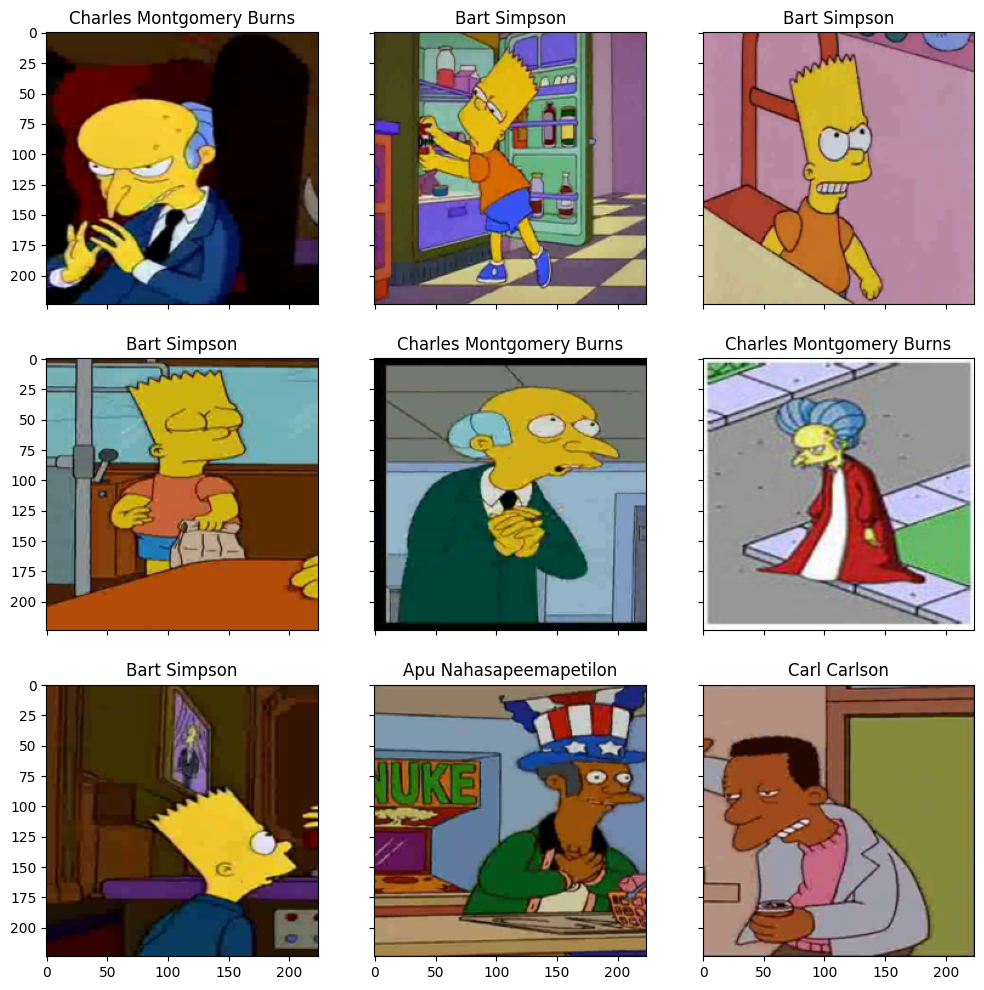

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

Первая сеть: самодельная SimpleCnn.

Cостоит из пяти сверточных слоев, каждый из которых
включает в себя операцию свертки, BatchNorm, функцию активации ReLU и операцию пулинга (max-pooling). После используется Dropout. На выходе используется полносвязный слой для классификации на заданное количество классов.

In [ ]:
class SimpleCnn(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        logits = self.out(x)
        return logits

Функция обучает модель на одной эпохе, используя предоставленный dataloader.

In [ ]:
def fit_epoch(model, train_loader, criterion, optimizer):

    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += (preds == labels).sum().item()
        processed_data += inputs.size(0)
    train_loss = running_loss / processed_data
    train_acc = running_corrects / processed_data
    return train_loss, train_acc

Функция оценивает работу модели на валидационном наборе данных за одну эпоху.

In [ ]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0
    processed_data = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += (preds == labels).sum().item()
        processed_data += inputs.size(0)
    val_loss = running_loss / processed_data
    val_acc = running_corrects / processed_data
    return val_loss, val_acc

Функция обучает модель на обучающем наборе данных и оценивает ее на валидационном наборе данных.

In [ ]:
def train(train_files, val_files, model, epochs, batch_size, num_workers):

    train_loader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        opt = torch.optim.Adam(model.parameters())
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, opt)
            print("loss", train_loss)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))

    return history

Эта функция принимает модель и загрузчик тестовых данных, применяет модель к
изображениям и возвращает вероятности предсказанных классов.

In [ ]:
def predict(model, test_loader):

    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [ ]:
n_classes = len(np.unique(train_val_labels))
simple_cnn = SimpleCnn(n_classes).to(DEVICE)
print("we will classify :{}".format(n_classes))
print(simple_cnn)

we will classify :42
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:
if val_dataset is None:
    val_dataset = SimpsonsDataset(val_files, mode='val')

train_dataset = SimpsonsDataset(train_files, mode='train')

Обучим нашу SimpleSnn на пяти эпохах, размер батча выберем 32.

In [ ]:
history_simple = train(train_dataset, val_dataset, model=simple_cnn, epochs=5, batch_size=32, num_workers=2)

epoch:   0%|          | 0/5 [00:00<?, ?it/s]

loss 2.1901912237551646


epoch:  20%|██        | 1/5 [02:05<08:22, 125.58s/it]


Epoch 001 train_loss: 2.1902     val_loss 1.4933 train_acc 0.4140 val_acc 0.6001
loss 1.2478788288294627


epoch:  40%|████      | 2/5 [03:23<04:52, 97.65s/it] 

...


Epoch 003 train_loss: 0.8735     val_loss 0.8381 train_acc 0.7571 val_acc 0.7717
loss 0.6910564329443604


epoch:  80%|████████  | 4/5 [06:00<01:24, 84.77s/it]


Epoch 004 train_loss: 0.6911     val_loss 0.7578 train_acc 0.8087 val_acc 0.8026
loss 0.5667592632982396


epoch: 100%|██████████| 5/5 [07:17<00:00, 87.57s/it]


Epoch 005 train_loss: 0.5668     val_loss 0.6660 train_acc 0.8367 val_acc 0.8286


Запомнили: за 7:17 минут достигли 0.8286 на валидационной выборке.

Вторая сеть: ResNet18. Посмотрим, насколько файнтьюнинг нам поможет.

In [ ]:
model_resnet = models.resnet18(weights=None)
model_resnet.load_state_dict(torch.load('/kaggle/input/resnet-weights/resnet18-f37072fd.pth', weights_only=True))

for name, param in model_resnet.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 42)
model_resnet = model_resnet.to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=0.001
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

Обучаем при тех же условиях.

In [ ]:
history_res = train(train_dataset, val_dataset, model=model_resnet, epochs=5, batch_size=32, num_workers=2)

epoch:   0%|          | 0/5 [00:00<?, ?it/s]

loss 0.6871526220278176


epoch:  20%|██        | 1/5 [01:19<05:17, 79.47s/it]


Epoch 001 train_loss: 0.6872     val_loss 0.3544 train_acc 0.8273 val_acc 0.9091
loss 0.4896047558986432


epoch:  40%|████      | 2/5 [02:37<03:55, 78.42s/it]

...


Epoch 003 train_loss: 0.3374     val_loss 0.4527 train_acc 0.9093 val_acc 0.8905
loss 0.24816350340776758


epoch:  80%|████████  | 4/5 [05:09<01:16, 76.96s/it]


Epoch 004 train_loss: 0.2482     val_loss 0.3596 train_acc 0.9337 val_acc 0.9117
loss 0.2097642411699082


epoch: 100%|██████████| 5/5 [06:26<00:00, 77.30s/it]


Epoch 005 train_loss: 0.2098     val_loss 0.3605 train_acc 0.9458 val_acc 0.9228


Вот, уже лучше! Теперь за 6:26 минут достигли 0.9228 на валидационной выборке.

Ну и третья сеть: EfficientNet-B0

In [ ]:
model_efficient = efficientnet_b0(weights=None)
model_efficient.load_state_dict(torch.load("/kaggle/input/efficientnet-b0/efficientnet_b0_rwightman-7f5810bc.pth", weights_only=True))

for name, param in model_efficient.named_parameters():
    if "classifier" in name or "features.6" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model_efficient.classifier[1].in_features
model_efficient.classifier[1] = nn.Linear(num_ftrs, 42)

model_efficient = model_efficient.to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_efficient.parameters()),
    lr=0.001
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

Смотрим:

In [ ]:
history_eff = train(train_dataset, val_dataset, model=model_efficient, epochs=5, batch_size=32, num_workers=2)

epoch:   0%|          | 0/5 [00:00<?, ?it/s]

loss 0.7580191345854667


epoch:  20%|██        | 1/5 [01:23<05:33, 83.36s/it]


Epoch 001 train_loss: 0.7580     val_loss 0.2263 train_acc 0.8192 val_acc 0.9438
loss 0.3461068916105527


epoch:  40%|████      | 2/5 [02:44<04:06, 82.15s/it]

...


Epoch 003 train_loss: 0.1561     val_loss 0.2358 train_acc 0.9561 val_acc 0.9410
loss 0.10255521507172613


epoch:  80%|████████  | 4/5 [05:27<01:21, 81.42s/it]


Epoch 004 train_loss: 0.1026     val_loss 0.2187 train_acc 0.9716 val_acc 0.9459
loss 0.09129512707639162


epoch: 100%|██████████| 5/5 [06:47<00:00, 81.51s/it]


Epoch 005 train_loss: 0.0913     val_loss 0.1913 train_acc 0.9749 val_acc 0.9561


Вау, 0.9561! За 06:47 и 5 эпох! Сюда!!!

In [ ]:
torch.save(model_efficient.state_dict(), "efficientnet_fine.pth")

Посмотрим на результат работы всех трех сетей:

In [ ]:
all_histories = {
    'SimpleCNN': history_simple,
    'ResNet18': history_res,
    'EfficientNet-B0': history_eff
}

In [ ]:
import matplotlib.pyplot as plt

def plot_history(all_histories):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for name, history in all_histories.items():
        val_acc = [epoch[3] for epoch in history]
        plt.plot(val_acc, label=name)
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    for name, history in all_histories.items():
        val_loss = [epoch[2] for epoch in history]
        plt.plot(val_loss, label=name)
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


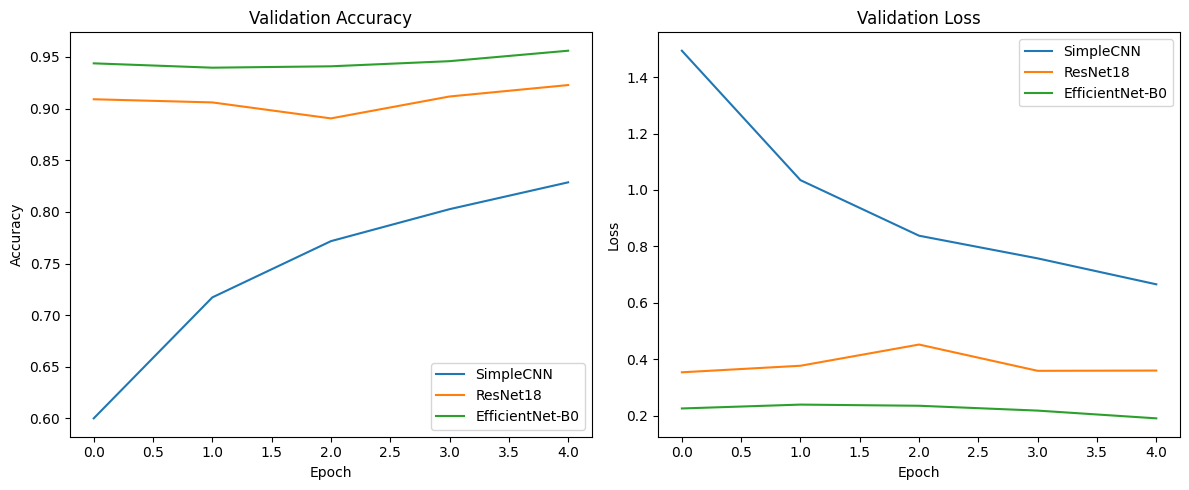

In [ ]:
plot_history(all_histories)

Победитель очевиден!

In [ ]:
best_model = model_efficient

Сделаем прогон на большем количестве эпох и батч выберем побольше.

In [ ]:
history = train(train_dataset, val_dataset, model=best_model, epochs=7, batch_size=64, num_workers=2)

epoch:   0%|          | 0/7 [00:00<?, ?it/s]

loss 0.07664854121325937


epoch:  14%|█▍        | 1/7 [01:18<07:52, 78.73s/it]


Epoch 001 train_loss: 0.0766     val_loss 0.1747 train_acc 0.9785 val_acc 0.9585
loss 0.08102239672082956


epoch:  29%|██▊       | 2/7 [02:37<06:32, 78.56s/it]

...


Epoch 005 train_loss: 0.0348     val_loss 0.2037 train_acc 0.9890 val_acc 0.9582
loss 0.03144797264933548


epoch:  86%|████████▌ | 6/7 [07:49<01:18, 78.14s/it]


Epoch 006 train_loss: 0.0314     val_loss 0.1843 train_acc 0.9912 val_acc 0.9597
loss 0.03383035853806973


epoch: 100%|██████████| 7/7 [09:07<00:00, 78.16s/it]


Epoch 007 train_loss: 0.0338     val_loss 0.1769 train_acc 0.9900 val_acc 0.9631


In [ ]:
loss, acc, val_loss, val_acc = zip(*history)

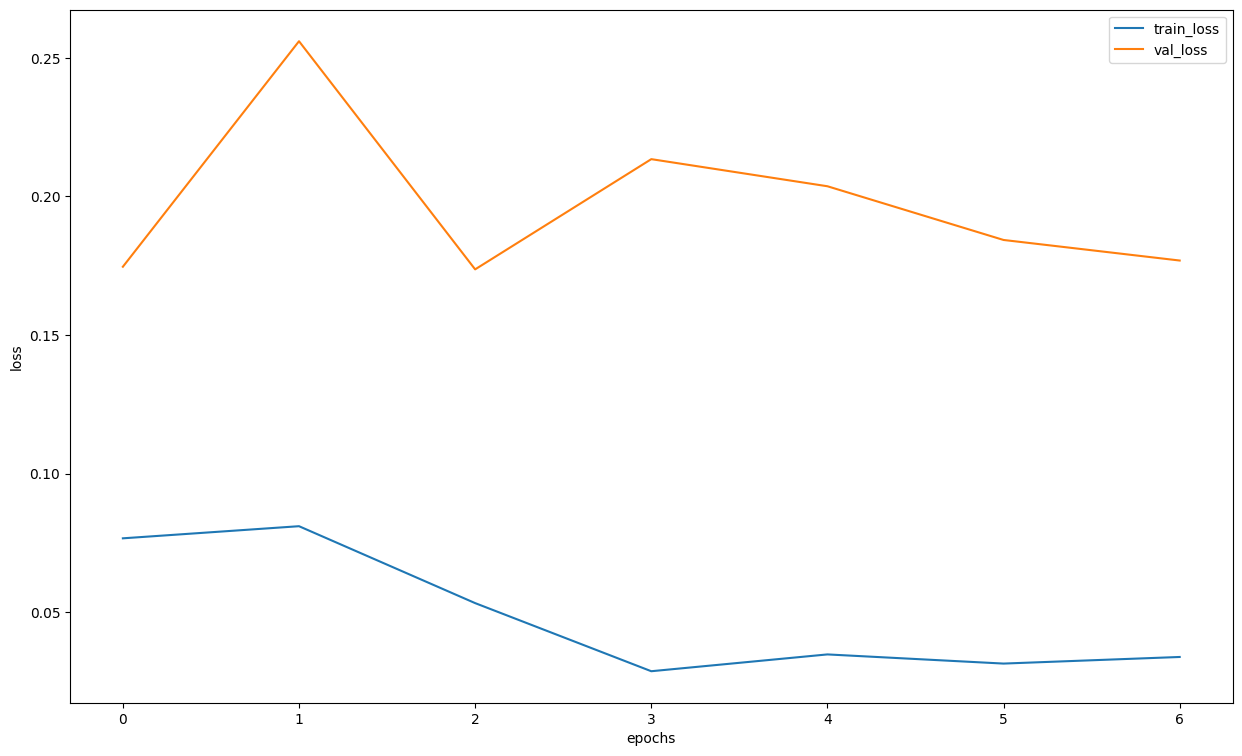

In [ ]:
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

Немного шумит, но не критично. Итак, финалочка:

Теперь мы можем перевести сеть в режим предсказания и получить вектор вероятностей того, что объект относится к тому или иному классу.

In [ ]:
def predict_one_sample(model, inputs, device=DEVICE):
    with torch.no_grad():
        inputs = inputs.to(device)
        model.eval()
        logit = model(inputs).cpu()
        probs = torch.nn.functional.softmax(logit, dim=-1).numpy()
    return probs

In [ ]:
random_characters = int(np.random.uniform(0,1000))
ex_img, true_label = val_dataset[random_characters]
probs_im = predict_one_sample(best_model, ex_img.unsqueeze(0))

idxs = list(map(int, np.random.uniform(0,1000, 20)))
imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]

probs_ims = predict(best_model, imgs)
label_encoder = pickle.load(open("label_encoder.pkl", 'rb'))
y_pred = np.argmax(probs_ims,-1)

actual_labels = [val_dataset[id][1] for id in idxs]

preds_class = [label_encoder.classes_[i] for i in y_pred]

Сделаем классную визуализацию, чтобы посмотреть насколько сеть уверена в своих ответах.

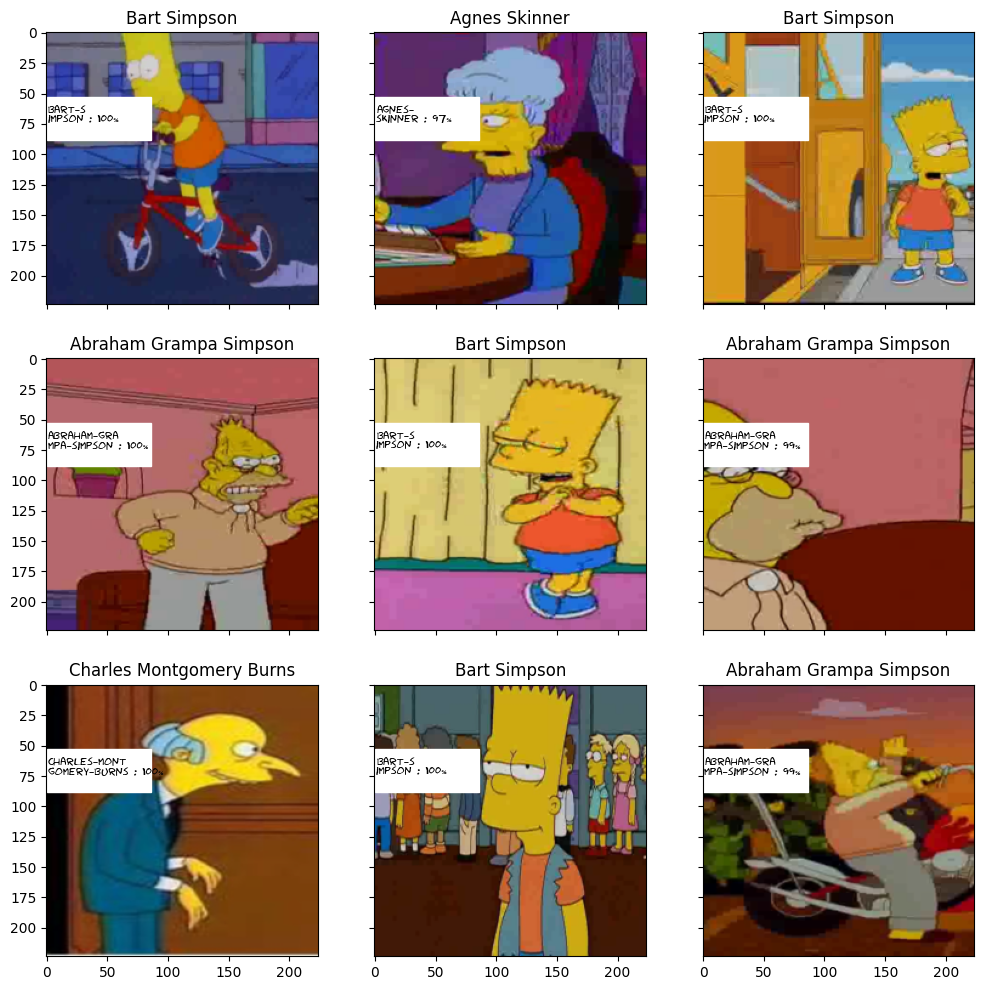

In [ ]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))



    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    fig_x.add_patch(patches.Rectangle((0, 53),86,35,color='white'))
    font0 = FontProperties()
    font = font0.copy()
    font.set_family("fantasy")
    prob_pred = predict_one_sample(best_model, im_val.unsqueeze(0))
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_label = predicted_label[:len(predicted_label)//2] + '\n' + predicted_label[len(predicted_label)//2:]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(1, 59, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')

Сохраним веса нашей модели:

In [ ]:
torch.save(best_model.state_dict(), "best_simpsons.pth")

In [ ]:
state_dict = torch.load("best_simpsons.pth", weights_only=True)
best_model.load_state_dict(state_dict)
best_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Ну и сделаем сабмит.

In [ ]:
test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)
probs = predict(best_model, test_loader)


preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
test_filenames = [path.name for path in test_dataset.files]

In [ ]:
submission = pd.DataFrame({
    "Id": test_filenames,
    "Expected": preds
})

submission.to_csv("submission.csv", index=False)

In [ ]:
submission.head(5)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon


Упорядочим по возрастанию (надо для ИИ Старт)

In [ ]:
submission['Id_num'] = submission['Id'].str.extract(r'img(\d+)\.jpg').astype(int)
submission_sorted = submission.sort_values('Id_num')
submission_sorted = submission_sorted.drop(columns='Id_num')
submission_sorted.to_csv("submission_sorted_ef.csv", index=False)

In [ ]:
submission_sorted.head(11)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
112,img2.jpg,mayor_quimby
223,img3.jpg,nelson_muntz
334,img4.jpg,lisa_simpson
445,img5.jpg,principal_skinner
556,img6.jpg,krusty_the_clown
667,img7.jpg,apu_nahasapeemapetilon
778,img8.jpg,principal_skinner
889,img9.jpg,comic_book_guy


In [ ]:
submission["Expected"].value_counts()

Expected
ned_flanders                53
bart_simpson                51
comic_book_guy              51
lisa_simpson                51
homer_simpson               51
chief_wiggum                50
principal_skinner           50
kent_brockman               50
edna_krabappel              50
marge_simpson               50
moe_szyslak                 50
apu_nahasapeemapetilon      50
krusty_the_clown            50
milhouse_van_houten         49
lenny_leonard               49
mayor_quimby                49
sideshow_bob                48
nelson_muntz                47
abraham_grampa_simpson      46
charles_montgomery_burns    46
Name: count, dtype: int64

In [ ]:
submission_sorted["Expected"].value_counts()

Expected
ned_flanders                53
bart_simpson                51
comic_book_guy              51
lisa_simpson                51
homer_simpson               51
edna_krabappel              50
kent_brockman               50
principal_skinner           50
apu_nahasapeemapetilon      50
krusty_the_clown            50
moe_szyslak                 50
marge_simpson               50
chief_wiggum                50
mayor_quimby                49
lenny_leonard               49
milhouse_van_houten         49
sideshow_bob                48
nelson_muntz                47
charles_montgomery_burns    46
abraham_grampa_simpson      46
Name: count, dtype: int64

Итог таков :)

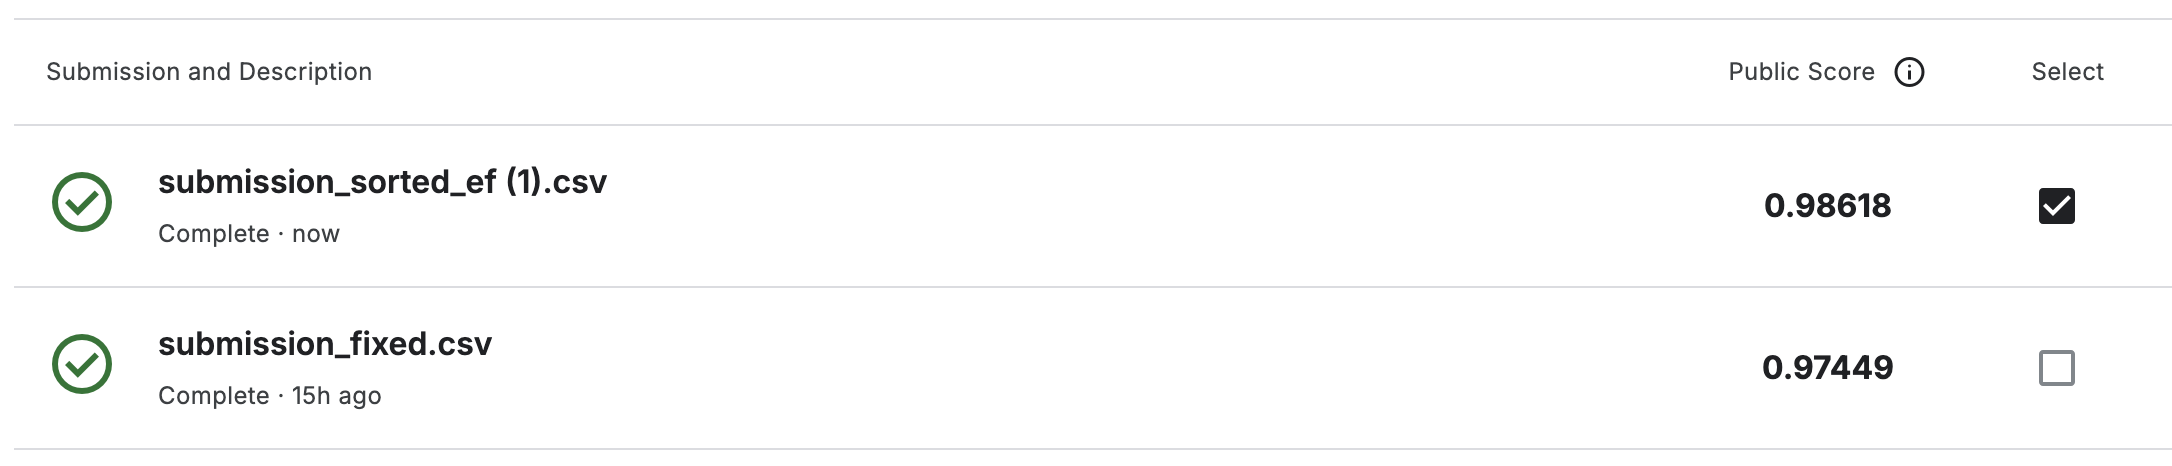

Предыдущее предсказание - от ResNet. 0.97449 - это вкусно, но 0.98618 вкуснее :)

Team name: Любовь_Мунтян_1013811396